In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import sys
import os


# feature_path = os.path.abspath(r"C:\Users\alexg\OneDrive\Documents\NBA-Prop-Predictor")
feature_path = os.path.abspath('/Users/alexg/Documents/Documents/Prize-Picks-Prop-Predictor')
if feature_path not in sys.path:
    sys.path.append(feature_path)

from FEATURE_ENGINEERING.features import *
from PROPS_EV.calculateEVS import *
from PROPS_EV.backtest import *

In [2]:
model = joblib.load('Models/xgbModel.pkl')
features = joblib.load('Models/top_features.pkl')

In [3]:
pd.set_option('display.max_columns', None)
eplison = 0.000001

s25 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_25.csv')
s25['EXPECTED_USAGE_MIN'] = s25['USG_PCT_ROLLING_AVG_5'] * (s25['MIN_ROLLING_AVG_5'] + eplison)

s24 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_24.csv')
s24['EXPECTED_USAGE_MIN'] = s24['USG_PCT_ROLLING_AVG_5'] * (s24['MIN_ROLLING_AVG_5'] + eplison)

df = pd.concat([s25, s24]).sort_values(by='GAME_DATE')

In [4]:
backtestData = pd.read_csv('../DATA/CSV_FILES/BACKTEST_DATA/dfs_data.csv')
backtestData = backtestData[(backtestData['CATEGORY'] == 'player_points') & (backtestData['BOOKMAKER'] == 'underdog')]
backtestData.head()

/var/folders/nw/9w4r5hrd05s122kt5hg_t8bw0000gn/T/ipykernel_55728/1365513428.py:1: DtypeWarning: Columns (11,12,14) have mixed types. Specify dtype option on import or set low_memory=False.
  backtestData = pd.read_csv('../DATA/CSV_FILES/BACKTEST_DATA/dfs_data.csv')


,Unnamed: 0.2,Unnamed: 0.1,Unnamed: 0,NAME,CATEGORY,BOOKMAKER,SIDE,LINE,ODDS,HOME_TEAM,AWAY_TEAM,game_id,commence_time,GAME_DATE,period_id,fair_line,fair_odds,OVER/ODDS
21,21,21,21,Josh Hart,player_points,underdog,over,8.5,-137,Boston Celtics,New York Knicks,92cf7db605a734b10e69eabf56e1eac9,2024-10-22T23:40:00Z,2024-10-22,NaN,NaN,NaN,over
22,22,22,22,Josh Hart,player_points,underdog,under,8.5,-137,Boston Celtics,New York Knicks,92cf7db605a734b10e69eabf56e1eac9,2024-10-22T23:40:00Z,2024-10-22,NaN,NaN,NaN,under
23,23,23,23,Luke Kornet,player_points,underdog,over,5.5,-137,Boston Celtics,New York Knicks,92cf7db605a734b10e69eabf56e1eac9,2024-10-22T23:40:00Z,2024-10-22,NaN,NaN,NaN,over
24,24,24,24,Luke Kornet,player_points,underdog,under,5.5,-137,Boston Celtics,New York Knicks,92cf7db605a734b10e69eabf56e1eac9,2024-10-22T23:40:00Z,2024-10-22,NaN,NaN,NaN,under
25,25,25,25,Sam Hauser,player_points,underdog,over,6.5,-137,Boston Celtics,New York Knicks,92cf7db605a734b10e69eabf56e1eac9,2024-10-22T23:40:00Z,2024-10-22,NaN,NaN,NaN,over


In [5]:
results = backtestPrizePicksPairs(df, backtestData, '2024-12-31')
results

Processing PrizePicks pairs...


,player1,player2,side1,side2,model_side1,model_side2,line1,line2,pred1,pred2,actual1,actual2,edge1,edge2,leg1_won,leg2_won,pair_recommendation,pair_won,ev_percent,probability,kelly_full,date
0,Amir Coffey,Jeremy Sochan,over,over,OVER,UNDER,8.5,13.5,12.94,6.59,14,4,4.44,-6.91,1,1,0,1,1.587,0.8624,0.794,2024-12-31
1,Jeremy Sochan,Norman Powell,over,over,UNDER,UNDER,13.5,23.5,6.59,13.06,4,15,-6.91,-10.44,1,1,1,1,1.529,0.8432,0.765,2024-12-31
2,Amir Coffey,Ty Jerome,over,over,OVER,OVER,8.5,5.5,12.94,10.68,14,5,4.44,5.18,1,0,0,0,1.513,0.8377,0.757,2024-12-31
3,Amir Coffey,Anthony Edwards,over,under,OVER,OVER,8.5,23.5,12.94,29.41,14,20,4.44,5.91,1,0,0,0,1.465,0.8216,0.732,2024-12-31
4,James Harden,Jeremy Sochan,over,over,UNDER,UNDER,22.5,13.5,14.59,6.59,17,4,-7.91,-6.91,1,1,1,1,1.462,0.8208,0.731,2024-12-31
5,Norman Powell,Ty Jerome,over,over,UNDER,OVER,23.5,5.5,13.06,10.68,15,5,-10.44,5.18,1,0,1,0,1.457,0.8190,0.728,2024-12-31
6,Anthony Edwards,Norman Powell,under,over,OVER,UNDER,23.5,23.5,29.41,13.06,20,15,5.91,-10.44,0,1,1,0,1.410,0.8033,0.705,2024-12-31
7,James Harden,Ty Jerome,over,over,UNDER,OVER,22.5,5.5,14.59,10.68,17,5,-7.91,5.18,1,0,1,0,1.392,0.7973,0.696,2024-12-31
8,Anthony Edwards,James Harden,under,over,OVER,UNDER,23.5,22.5,29.41,14.59,20,17,5.91,-7.91,0,1,1,0,1.346,0.7820,0.673,2024-12-31
9,Jeremy Sochan,Ty Jerome,over,over,UNDER,OVER,13.5,5.5,6.59,10.68,4,5,-6.91,5.18,1,0,1,0,1.253,0.7508,0.626,2024-12-31


In [6]:
if not results.empty:
    # Overall metrics
    total_bets = len(results)
    total_wins = results['pair_won'].sum()
    win_rate = results['pair_won'].mean()
    
    # Metrics for recommended bets only
    recommended = results[results['pair_recommendation'] == 1]
    if not recommended.empty:
        rec_total = len(recommended)
        rec_wins = recommended['pair_won'].sum()
        rec_win_rate = recommended['pair_won'].mean()
        
        print(f"\n--- All Bets ---")
        print(f"Total: {total_bets}, Wins: {total_wins}, Win Rate: {win_rate:.2%}")
        print(f"\n--- Recommended Bets (Edge > 4.5) ---")
        print(f"Total: {rec_total}, Wins: {rec_wins}, Win Rate: {rec_win_rate:.2%}")


--- All Bets ---
Total: 10, Wins: 3, Win Rate: 30.00%

--- Recommended Bets (Edge > 4.5) ---
Total: 7, Wins: 2, Win Rate: 28.57%


In [7]:
uniqueDates = sorted(s25['GAME_DATE'].unique())
all_results = []

for i, date in enumerate(uniqueDates, 1):
    print(f"Processing {date}... {i}/{len(uniqueDates)}")
    
    try:
        date_results = backtestPrizePicksPairs(df, backtestData, date, edge_threshold=4.5, top_n=3)
        
        if not date_results.empty:
            all_results.append(date_results)
            print(f"  ✓ Processed {len(date_results)} bets")
        else:
            print(f"  No results for {date}")
        
    except Exception as e:
        print(f"  ✗ Error: {e}")
        continue

# Combine all results
if all_results:
    final_results = pd.concat(all_results, ignore_index=True)
    print(f"\n✓ Complete! Total bets analyzed: {len(final_results)}")



Processing 2024-10-22... 1/163
Processing PrizePicks pairs...
  ✓ Processed 3 bets
Processing 2024-10-23... 2/163
Processing PrizePicks pairs...
  ✓ Processed 3 bets
Processing 2024-10-24... 3/163
Processing PrizePicks pairs...
  ✓ Processed 3 bets
Processing 2024-10-25... 4/163
Processing PrizePicks pairs...
  ✓ Processed 3 bets
Processing 2024-10-26... 5/163
Processing PrizePicks pairs...
  ✓ Processed 3 bets
Processing 2024-10-27... 6/163
Processing PrizePicks pairs...
  ✓ Processed 3 bets
Processing 2024-10-28... 7/163
Processing PrizePicks pairs...
  ✓ Processed 3 bets
Processing 2024-10-29... 8/163
Processing PrizePicks pairs...
  ✓ Processed 3 bets
Processing 2024-10-30... 9/163
Processing PrizePicks pairs...
  ✓ Processed 3 bets
Processing 2024-10-31... 10/163
Processing PrizePicks pairs...
  ✓ Processed 3 bets
Processing 2024-11-01... 11/163
Processing PrizePicks pairs...
  ✓ Processed 3 bets
Processing 2024-11-02... 12/163
Processing PrizePicks pairs...
  ✓ Processed 3 bets
P

           COMPREHENSIVE BETTING ANALYSIS

 ALL BETS ANALYSIS:
   Total Bets: 426
   Wins: 249
   Hit Rate: 58.45%
   Total Profit: $23.76
   Total Staked: $2,130.00
   ROI: 1.12%
   Volatility: $9.78
   Max Drawdown: $-162.26
   Sharpe Ratio: 0.204

 RECOMMENDED BETS ANALYSIS (Edge > 4.5):
   Total Bets: 208
   Wins: 137
   Hit Rate: 65.87%
   Total Profit: $145.00
   Total Staked: $1,040.00
   ROI: 13.94%
   Volatility: $7.44
   Max Drawdown: $-36.35
   Sharpe Ratio: 1.930


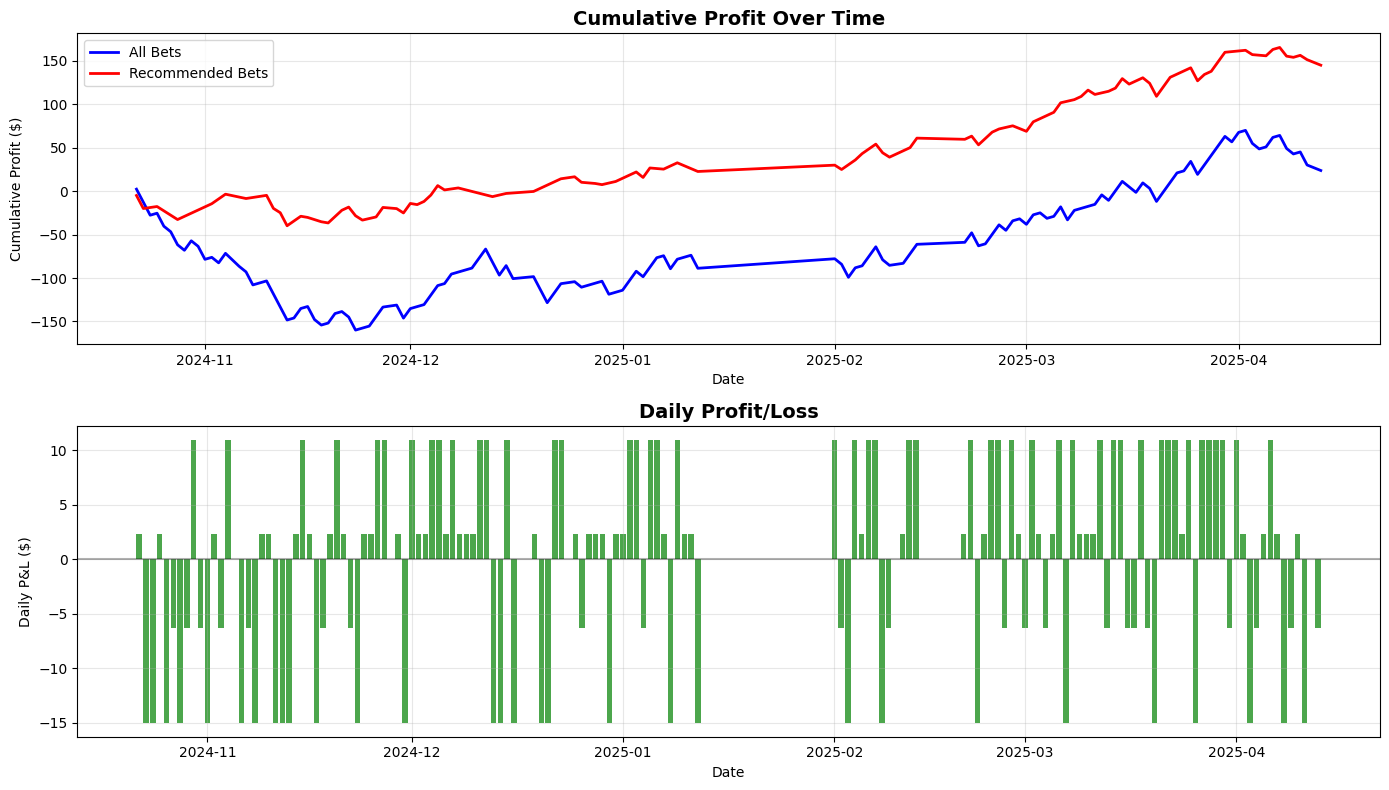

In [8]:
# Calculate metrics for all bets
all_metrics = calculatePairMetrics(final_results)

# Calculate metrics for recommended bets only
recommended = final_results[final_results['pair_recommendation'] == 1]
rec_metrics = calculatePairMetrics(recommended)

# Display comprehensive results
print("=" * 60)
print("           COMPREHENSIVE BETTING ANALYSIS")
print("=" * 60)

if all_metrics:
    print(f"\n ALL BETS ANALYSIS:")
    print(f"   Total Bets: {all_metrics['total_bets']:,}")
    print(f"   Wins: {all_metrics['total_wins']:,}")
    print(f"   Hit Rate: {all_metrics['win_rate']:.2%}")
    print(f"   Total Profit: ${all_metrics['total_profit']:,.2f}")
    print(f"   Total Staked: ${all_metrics['total_staked']:,.2f}")
    print(f"   ROI: {all_metrics['roi_percent']:.2f}%")
    print(f"   Volatility: ${all_metrics['volatility']:.2f}")
    print(f"   Max Drawdown: ${all_metrics['max_drawdown']:.2f}")
    print(f"   Sharpe Ratio: {all_metrics['sharpe_ratio']:.3f}")

if rec_metrics:
    print(f"\n RECOMMENDED BETS ANALYSIS (Edge > 4.5):")
    print(f"   Total Bets: {rec_metrics['total_bets']:,}")
    print(f"   Wins: {rec_metrics['total_wins']:,}")
    print(f"   Hit Rate: {rec_metrics['win_rate']:.2%}")
    print(f"   Total Profit: ${rec_metrics['total_profit']:,.2f}")
    print(f"   Total Staked: ${rec_metrics['total_staked']:,.2f}")
    print(f"   ROI: {rec_metrics['roi_percent']:.2f}%")
    print(f"   Volatility: ${rec_metrics['volatility']:.2f}")
    print(f"   Max Drawdown: ${rec_metrics['max_drawdown']:.2f}")
    print(f"   Sharpe Ratio: {rec_metrics['sharpe_ratio']:.3f}")

# Plots cumulative profit over time
if all_metrics and not all_metrics['daily_pnl'].empty:
    plt.figure(figsize=(14, 8))
    
    plt.subplot(2, 1, 1)
    plt.plot(all_metrics['daily_pnl']['date'], all_metrics['daily_pnl']['cumulative_profit'], 
             linewidth=2, label='All Bets', color='blue')
    if rec_metrics and not rec_metrics['daily_pnl'].empty:
        plt.plot(rec_metrics['daily_pnl']['date'], rec_metrics['daily_pnl']['cumulative_profit'], 
                 linewidth=2, label='Recommended Bets', color='red')
    plt.title('Cumulative Profit Over Time', fontsize=14, fontweight='bold')
    plt.xlabel('Date')
    plt.ylabel('Cumulative Profit ($)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.subplot(2, 1, 2)
    plt.bar(all_metrics['daily_pnl']['date'], all_metrics['daily_pnl']['profit'], 
            alpha=0.7, label='Daily P&L', color='green')
    plt.title('Daily Profit/Loss', fontsize=14, fontweight='bold')
    plt.xlabel('Date')
    plt.ylabel('Daily P&L ($)')
    plt.axhline(y=0, color='black', linestyle='-', alpha=0.3)
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()